In [1]:
import pandas as pd
import numpy as np
import seaborn as sns
from sklearn.model_selection import train_test_split
import seaborn as sns 
from sklearn.preprocessing import PolynomialFeatures
from sklearn import tree
from sklearn.linear_model import LogisticRegression
from sklearn.neighbors import KNeighborsClassifier
from sklearn.svm import SVC
from sklearn.model_selection import GridSearchCV,RandomizedSearchCV



In [2]:
colab_dataset_path="/content/drive/MyDrive/Colab Notebooks/data_sets"
local_dataset_path="/home/aerf123/my_projects/python/Data_analysis_and_science_and_ml/ml_class_project/Colab Notebooks/data_sets"
def setup_environment():
    """Setup environment and return CSV path"""
    try:
        import google.colab
        print("Running in Google Colab")
        
        # Mount Google Drive
        from google.colab import drive
        drive.mount('/content/drive')
        
        return f"{colab_dataset_path}/diabetes.csv"
        
    except ImportError:
        print("Running on local system")
        return f"{local_dataset_path}/diabetes.csv"

csv_path = setup_environment()
df = pd.read_csv(csv_path)
data=df

Running on local system


In [ ]:
from sklearn.model_selection import cross_val_score
from sklearn.model_selection import train_test_split

from sklearn.metrics import classification_report,confusion_matrix

from sklearn.metrics import root_mean_squared_error,mean_squared_error,r2_score,mean_absolute_error

def grading_classifier(estimator,x_features_train,y_target_train):
    x_train,x_val,y_train,y_val=train_test_split(x_features_train,y_target_train,random_state=42,test_size=0.25,stratify=y_target_train)

    y_hat=estimator.predict(x_val)
    return {"classification_report":classification_report(y_val,y_hat)
            ,"confusion_matrix":confusion_matrix(y_val,y_hat),
            "cross_val_score":cross_val_score(estimator=estimator,X=x_features_train,y=y_target_train,cv=5,n_jobs=5)}

def grading_regression(estimator,x_features_train,y_target_train,):
    x_train,x_val,y_train,y_val=train_test_split(x_features_train,y_target_train,random_state=42,test_size=0.25)

    y_hat=estimator.predict(x_val)
    return {"root_mean_squared_error":root_mean_squared_error(y_val,y_hat)
            ,"mean_squared_error":mean_squared_error(y_val,y_hat),
            "r2_score":r2_score(y_val,y_hat),
            "mean_absolute_error":mean_absolute_error(y_val,y_hat)}



In [4]:

def all_info(data):
    return {"head and tail of data":pd.concat([data.head(5),data.tail(5)]),
            "data_info":data.info,"data_describe":data.describe(),
            "data_isna":data.isna().sum(),"data_duplicated":data.duplicated().sum()}


data_information=all_info(df)
for i in data_information.keys():
    print(40*"^","\n",i,":\n",data_information[i],"\n",40*"-",3*"\n")

^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^ 
 head and tail of data :
      Pregnancies  Glucose  BloodPressure  SkinThickness  Insulin   BMI  \
0              6      148             72             35        0  33.6   
1              1       85             66             29        0  26.6   
2              8      183             64              0        0  23.3   
3              1       89             66             23       94  28.1   
4              0      137             40             35      168  43.1   
763           10      101             76             48      180  32.9   
764            2      122             70             27        0  36.8   
765            5      121             72             23      112  26.2   
766            1      126             60              0        0  30.1   
767            1       93             70             31        0  30.4   

     DiabetesPedigreeFunction  Age  Outcome  
0                       0.627   50        1  
1                       0

In [5]:
# Removing outlier (remove more than 99 percentile and less than 0.01 percentile)
# lower_quantile=data.iloc[:,:-1].quantile(0.01)
# higher_quantile=data.iloc[:,:-1].quantile(0.99)
# data_filtered = data[(data.iloc[:,:-1] < higher_quantile) & (data.iloc[:,:-1] > lower_quantile)]
# data_filtered.dropna(inplace=True)


<Axes: >

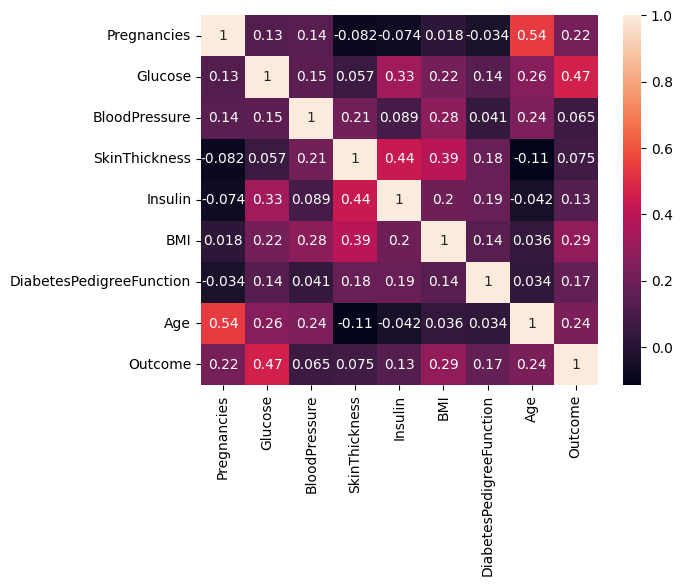

In [6]:
correlation=data.corr()
sns.heatmap(correlation,annot=True)

<Axes: xlabel='SkinThickness', ylabel='Insulin'>

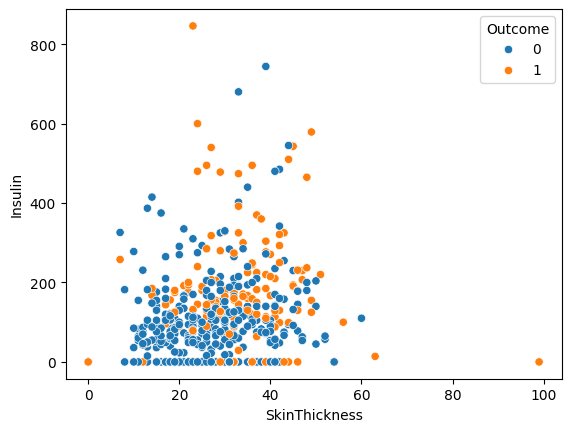

In [7]:
sns.scatterplot(data,x="SkinThickness",y="Insulin",hue="Outcome")

<Axes: xlabel='BMI', ylabel='Age'>

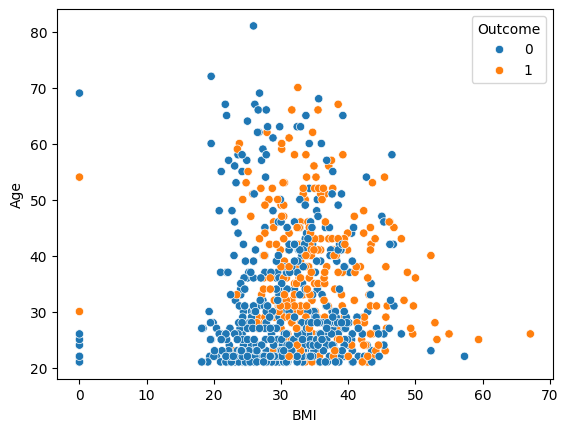

In [8]:
sns.scatterplot(data,x="BMI",y="Age",hue="Outcome")

<Axes: xlabel='Glucose', ylabel='Outcome'>

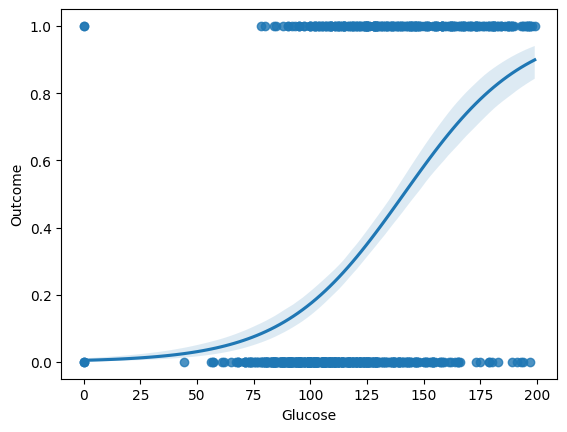

In [9]:
sns.regplot(data,y="Outcome",x="Glucose",logistic=True,scatter=True)

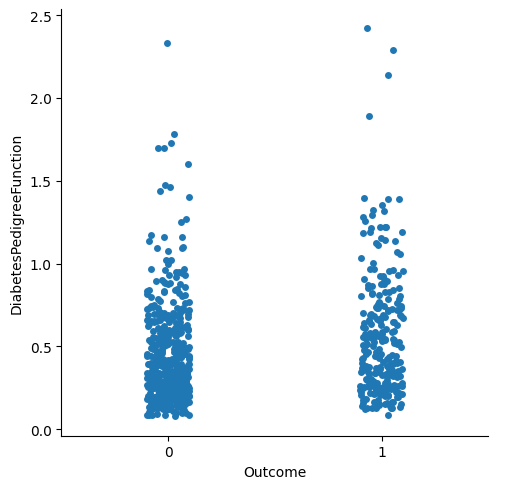

In [10]:
sns.catplot(data=data, y="DiabetesPedigreeFunction", x="Outcome")

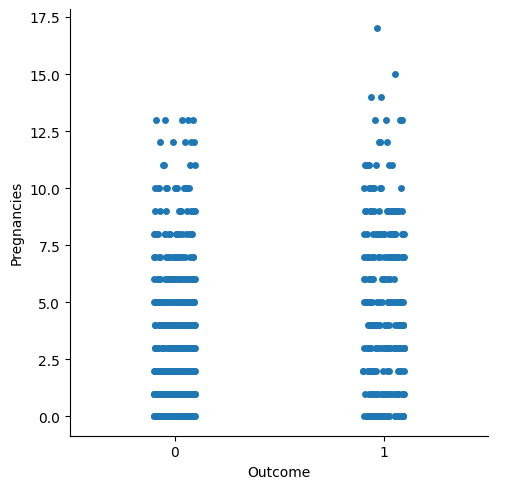

In [11]:
sns.catplot(data=data, y="Pregnancies", x="Outcome")

In [12]:
from sklearn.preprocessing import StandardScaler,Normalizer,RobustScaler


x_features_train=data.iloc[:,:-1]
y_target_train=data.iloc[:,-1]



scaler=StandardScaler()
scaled_x_features_train=scaler.fit_transform(x_features_train)
scaled_x_features_train=pd.DataFrame(scaled_x_features_train)


polynomialer=PolynomialFeatures(degree=2,include_bias=False)

poly_scaled_x_features_train=polynomialer.fit_transform(scaled_x_features_train)
poly_scaled_x_features_train=pd.DataFrame(poly_scaled_x_features_train)


poly_x_features_train=polynomialer.fit_transform(x_features_train)
poly_x_features_train=pd.DataFrame(poly_x_features_train)




              precision    recall  f1-score   support

           0       0.81      0.89      0.85       125
           1       0.75      0.61      0.67        67

    accuracy                           0.79       192
   macro avg       0.78      0.75      0.76       192
weighted avg       0.79      0.79      0.79       192
 
 ---------------------------------------- 



[[111  14]
 [ 26  41]] 
 ---------------------------------------- 



0.7487819370172311 
 ---------------------------------------- 





<Axes: >

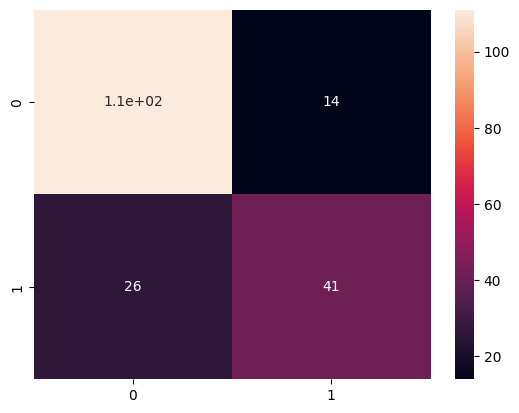

In [53]:
x_train,x_val,y_train,y_val=train_test_split(x_features_train,y_target_train,random_state=42,test_size=0.25,stratify=y_target_train)
our_tree=tree.DecisionTreeClassifier(max_depth=5,random_state=42)
our_tree.fit(x_train,y_train)

classifier_scores=grading_classifier(our_tree,x_features_train,y_target_train,)

for i in classifier_scores:
    if i =="cross_val_score":
        print(classifier_scores[i].mean(),"\n",40*"-",3*"\n")
        continue
    print(classifier_scores[i],"\n",40*"-",3*"\n")

sns.heatmap(classifier_scores["confusion_matrix"],annot=True)

              precision    recall  f1-score   support

           0       0.76      0.85      0.80       125
           1       0.64      0.51      0.57        67

    accuracy                           0.73       192
   macro avg       0.70      0.68      0.68       192
weighted avg       0.72      0.73      0.72       192
 
 ---------------------------------------- 



[[106  19]
 [ 33  34]] 
 ---------------------------------------- 



0.7500806383159324 
 ---------------------------------------- 





<Axes: >

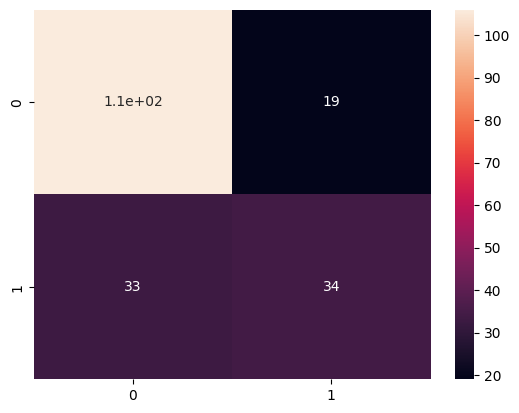

In [32]:

x_train,x_val,y_train,y_val=train_test_split(x_features_train,y_target_train,random_state=42,test_size=0.25,stratify=y_target_train)
knn=KNeighborsClassifier(n_neighbors=19,p=2)
knn.fit(x_train,y_train)

classifier_scores=grading_classifier(knn,x_features_train,y_target_train)
for i in classifier_scores:
    if i =="cross_val_score":
        print(classifier_scores[i].mean(),"\n",40*"-",3*"\n")
        continue
    print(classifier_scores[i],"\n",40*"-",3*"\n")

sns.heatmap(classifier_scores["confusion_matrix"],annot=True)

              precision    recall  f1-score   support

           0       0.77      0.84      0.80       125
           1       0.64      0.52      0.57        67

    accuracy                           0.73       192
   macro avg       0.70      0.68      0.69       192
weighted avg       0.72      0.73      0.72       192
 
 ---------------------------------------- 



[[105  20]
 [ 32  35]] 
 ---------------------------------------- 



0.7721925133689839 
 ---------------------------------------- 





<Axes: >

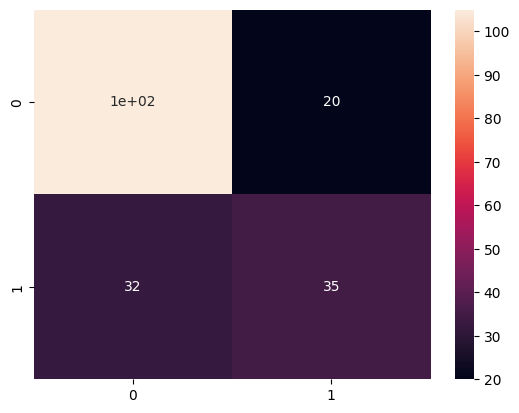

In [15]:

x_train, x_val, y_train, y_val = train_test_split(x_features_train, y_target_train,test_size=0.25, random_state=42, stratify=y_target_train)
log_reg = LogisticRegression(random_state=42,max_iter=1000)
log_reg.fit(x_train, y_train)

classifier_scores=grading_classifier(log_reg,x_features_train,y_target_train,)
for i in classifier_scores:
    if i =="cross_val_score":
        print(classifier_scores[i].mean(),"\n",40*"-",3*"\n")
        continue
    print(classifier_scores[i],"\n",40*"-",3*"\n")

sns.heatmap(classifier_scores["confusion_matrix"],annot=True)

              precision    recall  f1-score   support

           0       0.76      0.90      0.82       125
           1       0.72      0.46      0.56        67

    accuracy                           0.75       192
   macro avg       0.74      0.68      0.69       192
weighted avg       0.75      0.75      0.73       192
 
 ---------------------------------------- 



[[113  12]
 [ 36  31]] 
 ---------------------------------------- 



0.7669637551990492 
 ---------------------------------------- 





<Axes: >

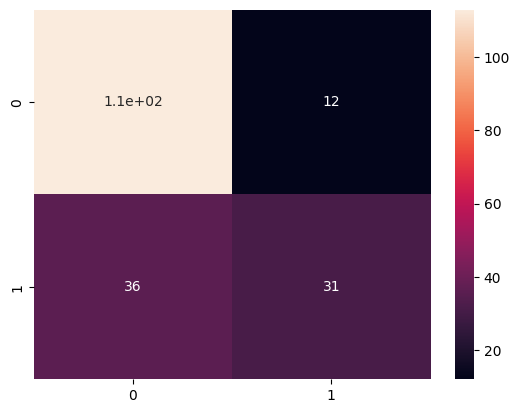

In [ ]:
x_train,x_val,y_train,y_val=train_test_split(x_features_train,y_target_train,random_state=42,test_size=0.25,stratify=y_target_train)
scv_classifier=SVC(random_state=42,C=1,kernel="poly",degree=2)
scv_classifier.fit(x_train,y_train)

classifier_scores=grading_classifier(scv_classifier,x_features_train,y_target_train,)
for i in classifier_scores:
    if i =="cross_val_score":
        print(classifier_scores[i].mean(),"\n",40*"-",3*"\n")
        continue
    print(classifier_scores[i],"\n",40*"-",3*"\n")

sns.heatmap(classifier_scores["confusion_matrix"],annot=True)

In [17]:
grid_parameters={"max_depth":[3,5,7,10,12,15,17,19],"random_state":[42]}
our_tree_grid=GridSearchCV(tree.DecisionTreeClassifier(), grid_parameters,cv=5,refit=True)
our_tree_grid.fit(x_features_train,y_target_train)

,estimator,DecisionTreeClassifier()
,param_grid,"{'max_depth': [3, 5, ...], 'random_state': [42]}"
,scoring,None
,n_jobs,None
,refit,True
,cv,5
,verbose,0
,pre_dispatch,'2*n_jobs'
,error_score,nan
,return_train_score,False
,criterion,'gini'


In [60]:

grid_parameters={"random_state":[42],"kernel":["poly"],"C":[0.1, 1, 10, 50],
                  "degree":[2,3],"coef0":[0.1,1,5,10]}

# grid_parameters={"random_state":[42],"kernel":["poly"],"degree":[2,3,4,5,6],"gamma":[0.001]}
scv_classifier_grid_poly=RandomizedSearchCV(SVC(), grid_parameters,cv=5,n_iter=32,random_state=42,refit=True,n_jobs=6)
scv_classifier_grid_poly.fit(scaled_x_features_train,y_target_train)

,estimator,SVC()
,param_distributions,"{'C': [0.1, 1, ...], 'coef0': [0.1, 1, ...], 'degree': [2, 3], 'kernel': ['poly'], ...}"
,n_iter,32
,scoring,None
,n_jobs,-1
,refit,True
,cv,5
,verbose,0
,pre_dispatch,'2*n_jobs'
,random_state,42
,error_score,nan


In [19]:

grid_parameters={"random_state":[42],"kernel":["rbf","linear"],"C":np.arange(0.1,4,0.8),
                 "gamma":[0.25,0.5,2,7,18]}
scv_classifier_grid=RandomizedSearchCV(SVC(), grid_parameters,cv=5,n_iter=50,random_state=42,refit=True)
scv_classifier_grid.fit(scaled_x_features_train,y_target_train)

,estimator,SVC()
,param_distributions,"{'C': array([0.1, 0....7, 2.5, 3.3]), 'gamma': [0.25, 0.5, ...], 'kernel': ['rbf', 'linear'], 'random_state': [42]}"
,n_iter,50
,scoring,None
,n_jobs,None
,refit,True
,cv,5
,verbose,0
,pre_dispatch,'2*n_jobs'
,random_state,42
,error_score,nan


In [20]:
grid_parameters={"random_state":[42],"max_iter":[1000],"C":[0.5,1,2,3,5]}
log_reg_grid=GridSearchCV(LogisticRegression(), grid_parameters,cv=5,refit=True)
log_reg_grid.fit(x_features_train,y_target_train)

,estimator,LogisticRegression()
,param_grid,"{'C': [0.5, 1, ...], 'max_iter': [1000], 'random_state': [42]}"
,scoring,None
,n_jobs,None
,refit,True
,cv,5
,verbose,0
,pre_dispatch,'2*n_jobs'
,error_score,nan
,return_train_score,False
,penalty,'l2'


In [21]:
grid_parameters={"n_neighbors":np.arange(1,30,1),"p":[1,2,3,4,5]}
knn_grid=GridSearchCV(KNeighborsClassifier(), grid_parameters,cv=5,refit=True)
knn_grid.fit(x_features_train,y_target_train)


,estimator,KNeighborsClassifier()
,param_grid,"{'n_neighbors': array([ 1, 2..., 27, 28, 29]), 'p': [1, 2, ...]}"
,scoring,None
,n_jobs,None
,refit,True
,cv,5
,verbose,0
,pre_dispatch,'2*n_jobs'
,error_score,nan
,return_train_score,False
,n_neighbors,np.int64(14)


In [ ]:


grading_classifier(knn_grid,x_features_train,y_target_train)
for i in classifier_scores:
    if i =="cross_val_score":
        print(classifier_scores[i].mean(),"\n",40*"-",3*"\n")
        continue
    print(classifier_scores[i],"\n",40*"-",3*"\n")






              precision    recall  f1-score   support

           0       0.76      0.90      0.82       125
           1       0.72      0.46      0.56        67

    accuracy                           0.75       192
   macro avg       0.74      0.68      0.69       192
weighted avg       0.75      0.75      0.73       192
 
 ---------------------------------------- 



[[113  12]
 [ 36  31]] 
 ---------------------------------------- 



0.7669637551990492 
 ---------------------------------------- 





In [23]:
grading_classifier(log_reg_grid,x_features_train,y_target_train)
for i in classifier_scores:
    if i =="cross_val_score":
        print(classifier_scores[i].mean(),"\n",40*"-",3*"\n")
        continue
    print(classifier_scores[i],"\n",40*"-",3*"\n")





              precision    recall  f1-score   support

           0       0.76      0.90      0.82       125
           1       0.72      0.46      0.56        67

    accuracy                           0.75       192
   macro avg       0.74      0.68      0.69       192
weighted avg       0.75      0.75      0.73       192
 
 ---------------------------------------- 



[[113  12]
 [ 36  31]] 
 ---------------------------------------- 



0.7669637551990492 
 ---------------------------------------- 





In [24]:
grading_classifier(scv_classifier_grid,scaled_x_features_train,y_target_train)
for i in classifier_scores:
    if i =="cross_val_score":
        print(classifier_scores[i].mean(),"\n",40*"-",3*"\n")
        continue
    print(classifier_scores[i],"\n",40*"-",3*"\n")


              precision    recall  f1-score   support

           0       0.76      0.90      0.82       125
           1       0.72      0.46      0.56        67

    accuracy                           0.75       192
   macro avg       0.74      0.68      0.69       192
weighted avg       0.75      0.75      0.73       192
 
 ---------------------------------------- 



[[113  12]
 [ 36  31]] 
 ---------------------------------------- 



0.7669637551990492 
 ---------------------------------------- 





In [58]:
grading_classifier(scv_classifier_grid_poly,scaled_x_features_train,y_target_train)
for i in classifier_scores:
    if i =="cross_val_score":
        print(classifier_scores[i].mean(),"\n",40*"-",3*"\n")
        continue
    print(classifier_scores[i],"\n",40*"-",3*"\n")


              precision    recall  f1-score   support

           0       0.81      0.89      0.85       125
           1       0.75      0.61      0.67        67

    accuracy                           0.79       192
   macro avg       0.78      0.75      0.76       192
weighted avg       0.79      0.79      0.79       192
 
 ---------------------------------------- 



[[111  14]
 [ 26  41]] 
 ---------------------------------------- 



0.7487819370172311 
 ---------------------------------------- 





In [57]:
grading_classifier(our_tree_grid,x_features_train,y_target_train)
for i in classifier_scores:
    if i =="cross_val_score":
        print(classifier_scores[i].mean(),"\n",40*"-",3*"\n")
        continue
    print(classifier_scores[i],"\n",40*"-",3*"\n")


              precision    recall  f1-score   support

           0       0.81      0.89      0.85       125
           1       0.75      0.61      0.67        67

    accuracy                           0.79       192
   macro avg       0.78      0.75      0.76       192
weighted avg       0.79      0.79      0.79       192
 
 ---------------------------------------- 



[[111  14]
 [ 26  41]] 
 ---------------------------------------- 



0.7487819370172311 
 ---------------------------------------- 



